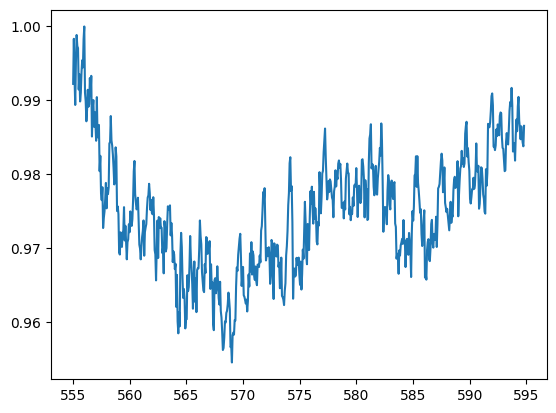

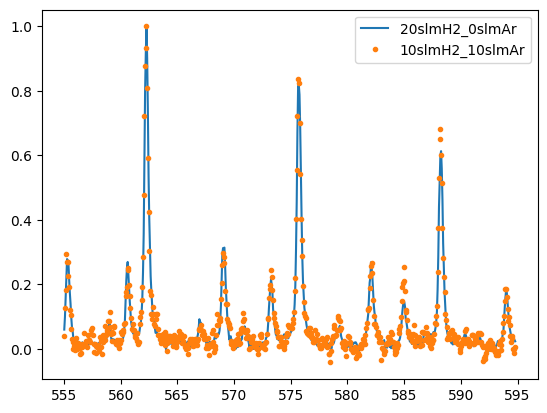

In [1]:
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from toddler.data.spectrum import Spectrum
import wedme

dir_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250114/")

def get_data_for_meas(f_fg):
    f_bg = f_fg.with_stem(f_fg.stem + "_bg")

    s_fg = Spectrum.from_file(f_fg, new_axes=True).median(axis=2)
    s_fg._axis_lambda = 0

    s_bg = Spectrum.from_file(f_bg, new_axes=True).median(axis=2)
    s_bg._axis_lambda = 0

    s_raman = s_fg - s_bg

    # plt.figure()
    # plt.plot(s_fg.lambdanm, s_fg.sdata, label="fg")
    # plt.plot(s_bg.lambdanm, s_bg.sdata, label="bg")
    # plt.plot(s_raman.lambdanm, s_raman.sdata, label="fg-bg") 

    return s_raman.squeeze().slice(lambda_start=555e-9).normalize(axis=0)


s_lamp = get_data_for_meas(dir_data / "01_lamp_g2l532.sif")
s_ref = Spectrum.from_csv("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/Calibration/SLS201L_intensity_calibration.csv", 1e-9) 
eff = ((s_ref @ s_lamp) / s_lamp).normalize(axis=0)

s_roomtemp = (get_data_for_meas(dir_data / "01_200mbar_roomtemp_g2l532.sif") / eff).normalize(axis=0)
s_20slmH2_0slmAr = (get_data_for_meas(dir_data / "01_200mbar_20slmH2_0slmAr_1000W_g2l532.sif") / eff).normalize(axis=0)
s_10slmH2_10slmAr = (get_data_for_meas(dir_data / "01_200mbar_10slmH2_10slmAr_1000W_g2l532.sif") / eff).normalize(axis=0)

plt.figure()
plt.plot(eff.lambdanm, eff.sdata, label="eff")

plt.figure()
plt.plot(s_20slmH2_0slmAr.lambdanm, s_20slmH2_0slmAr.sdata, label="20slmH2_0slmAr")
plt.plot(s_10slmH2_10slmAr.lambdanm, s_10slmH2_10slmAr.sdata, '.', label="10slmH2_10slmAr")
plt.legend()
plt.show()

In [31]:
# %load_ext line_profiler

from lmfit import minimize, Parameters, fit_report
from ramlab.simulate.linespreadfunction.functions import gaussian, voigt, lorentzian, rect, martijnian
from ramlab.molecules.H2 import H2
import matplotlib.pyplot as plt
import wedme.apply.dev
import numpy as np
from ramlab.molecules.calculated_linelist_molecule import CalculatedLinelistMolecule
from ramlab.simulate import simulate, simulate_raw, subsampled
import lmfit
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt

from ttictoc import tic,toc


from ramlab.fit.modifiers import *
from ramlab.molecules.polarisation import Polarisation


# M = CalculatedLinelistMolecule(H2)
M = H2
transitions = M.get_all_transitions(laser_wavelength=532e-9)
transitions = transitions[transitions.dv == 0]
# transitions = transitions[transitions.initial_v == 0]
transitions = transitions[transitions.dJ == 2]
transitions = transitions[transitions.initial_J < 10]
transitions = transitions[transitions.crosssection != np.nan]

I_const_par = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PARALLEL)
I_const_per = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PERPENDICULAR)
I_const_tot = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.COMBINED)
I_var = M.get_intensity_variable(transitions, T=300)


fitParameters = Parameters()
fitParameters.add("A", value=1, min=0.9, max=1.1, vary=True)
fitParameters.add("T", value=2000, min=250, max=10e3, vary=True)
fitParameters.add("w_g", value=0.10846304, min=0, vary=False)
fitParameters.add("w_l", value=0.11559744, min=0, vary=False)

wavelengthCorrection = WavelengthAxisCorrection(1)
wavelengthCorrection.add_parameters(fitParameters, initial_values=[0.65650120, -0.12803481], vary=False)

def spectral_fit_residuals(pars: Parameters, meas, I_const_per, I_const_par, test=False):
    tic()
    A = pars['A']
    T = pars['T']
    w_g = pars['w_g']
    w_l = pars['w_l']

    meas = MeasurementSpectrum(meas)
    meas = wavelengthCorrection.modify(meas, pars)

    meas = meas.data
    dnu_meas = meas.dnu()/1e2, 
    lambda_meas = meas.lambdanm
    I_meas = meas.c.normalize(axis=0).sdata


    I_var = M.get_intensity_variable(transitions, T=T)
    # I_stick_sim = (I_const_per) * I_var
    I_stick_sim = (I_const_tot) * I_var
    # I_stick_sim = (I_const_per + I_const_par) * I_var
    I_stick_sim /= np.nanmax(I_stick_sim)

    dnu_stick = transitions.vacuum_wavenumber
    dnu_scat = 1/532e-9 - dnu_stick*1e2
    lambda_stick = 1e9/dnu_scat

    I_sim_broad = subsampled(lambda_meas, lambda_stick, I_stick_sim, w_g, w_l)
    # I_sim_broad = simulate_raw(dnu_meas, dnu_stick, I_stick_sim, w_g, w_l)
    I_sim_broad *= A / np.nanmax(I_sim_broad)

    # print(f"Execution time: {toc()*1e3:.0f}ms")

    if test is True:
        return I_sim_broad

    return (I_sim_broad - I_meas)**2

# s = s_20slmH2_0slmAr # T=3208 +/- 13 / 3166 +- 13
# s = s_roomtemp # T=3478 +/- 25
s = s_10slmH2_10slmAr # T=3478 +/- 25 / 3433 +- 18
out = minimize(spectral_fit_residuals, fitParameters, args=(s.c.normalize(axis=0), I_const_per, I_const_par), )
spectral_fit_residuals(fitParameters, s.c.normalize(axis=0), I_const_per, I_const_par, test=True)

print(fit_report(out))

Calculating cross-section
Calculating cross-section
Calculating cross-section
Calculating cross-section
Calculating cross-section
Execution time: 29ms
Execution time: 42ms
Execution time: 30ms
Execution time: 43ms
Execution time: 28ms
Execution time: 41ms
Execution time: 29ms
Execution time: 42ms
Execution time: 28ms
Execution time: 41ms
Execution time: 28ms
Execution time: 41ms
Execution time: 28ms
Execution time: 42ms
Execution time: 28ms
Execution time: 41ms
Execution time: 29ms
Execution time: 43ms
Execution time: 28ms
Execution time: 41ms
Execution time: 28ms
Execution time: 42ms
Execution time: 28ms
Execution time: 41ms
Execution time: 29ms
Execution time: 44ms
Execution time: 28ms
Execution time: 41ms
Execution time: 29ms
Execution time: 42ms
Execution time: 29ms
Execution time: 42ms
Execution time: 28ms
Execution time: 42ms
Execution time: 28ms
Execution time: 42ms
Execution time: 27ms
Execution time: 41ms
Execution time: 28ms
Execution time: 42ms
Execution time: 29ms
Execution

<Parameter 'T', value=np.float64(3517.9549693226045) +/- 60.7, bounds=[250:10000.0]>
Execution time: 44ms


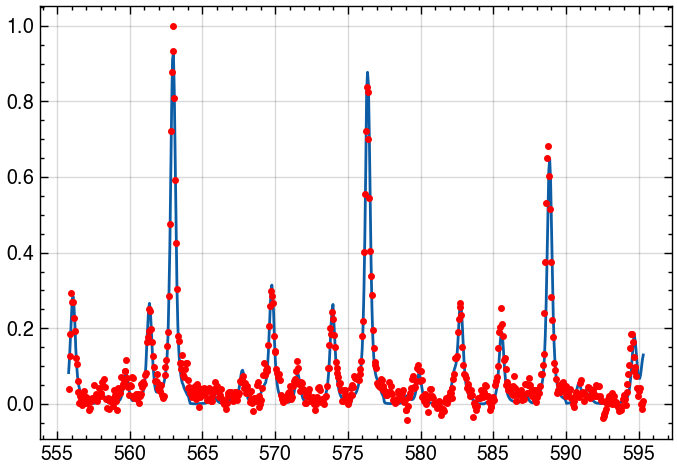

Execution time: 46ms


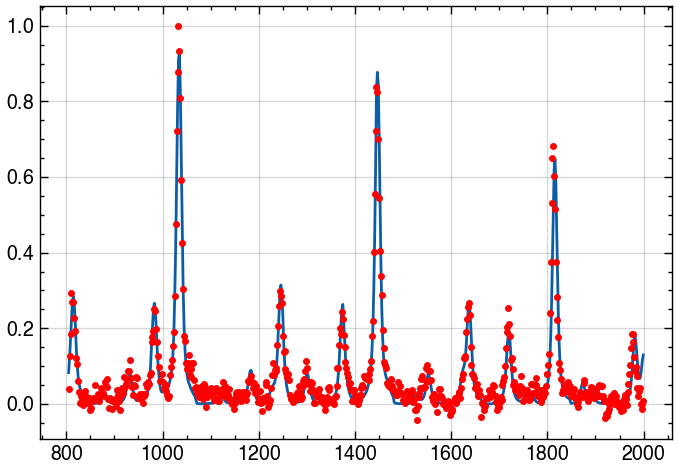

Execution time: 45ms


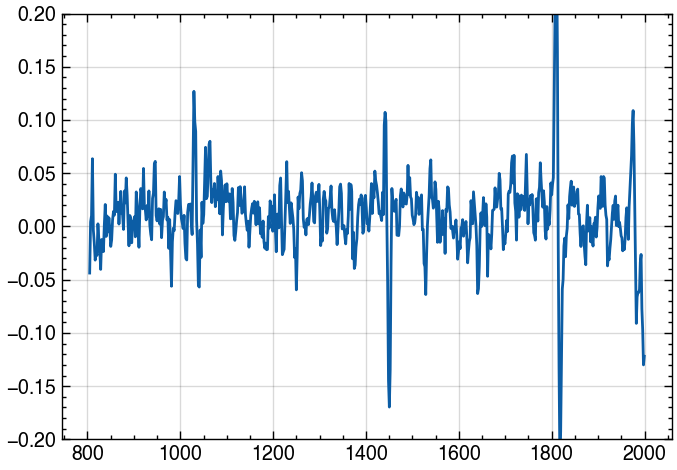

In [3]:
print(out.params['T'])
ver2 = wavelengthCorrection.modify(MeasurementSpectrum(s.c), out.params).data

plt.figure()
plt.plot(ver2.lambdanm, spectral_fit_residuals(out.params, s.c.normalize(axis=0), I_const_per, I_const_par, test=True))
plt.plot(ver2.lambdanm, s.sdata, 'r.')
plt.show()

plt.figure()
plt.plot(ver2.dnu()/1e2, spectral_fit_residuals(out.params, s.c.normalize(axis=0), I_const_per, I_const_par, test=True))
plt.plot(ver2.dnu()/1e2, s.sdata, 'r.')
plt.show()

plt.figure()
plt.plot(ver2.dnu()/1e2, ver2.sdata - spectral_fit_residuals(out.params, s.c.normalize(axis=0), I_const_per, I_const_par, test=True))
plt.ylim(-0.2, 0.2)
plt.show()
# plt.xlim(800, 1000)